# Woche 8: Visualisierung - Obesity


Explorative Datenanalyse mit bereinigten Daten aus Woche 7

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("Setup komplett")

Setup komplett


In [2]:
# Laden der bereinigten Daten aus Woche 7
df = pd.read_csv('obesity_cleaned.csv')
print(f"Geladen: {df.shape}")
display(df.head())

Geladen: (1653, 17)


,id,gender,age,education_lvl,income,kcal,protein,carbs,sugar,fiber,fat,alcohol,sedentary_act_min,smoke_status,activity_level,sleep_avg,bmi_cat
0,130379,1.0,66,5.0,5.00,2741.0,86.45,314.86,113.58,29.6,67.18,4,480.0,1.0,1,9.0,2
1,130386,1.0,34,4.0,1.33,2422.0,132.41,207.53,37.89,25.1,116.54,3,180.0,1.0,0,7.6,2
2,130389,1.0,59,5.0,5.00,1991.0,89.50,118.64,52.67,6.7,98.03,4,720.0,1.0,1,8.0,1
3,130394,1.0,51,5.0,5.00,1613.0,75.06,207.20,64.46,19.7,55.44,2,420.0,0.0,1,8.0,0
4,130398,1.0,47,3.0,1.67,1109.0,32.42,195.50,82.65,24.7,12.95,3,60.0,0.0,2,5.1,1


Der Datensatz enthält Daten zu 1653 Probanden.

### Legende:
- gender: 1 = Mann, 2 = Frau (divers wurde nicht abgefragt)
- age: gecappt bei 20 (jüngere Probanden wurden rausgefiltert) und 80 (80 steht für 80 Jahre und älter)
- education_lvl:
  - 1 = unter 9. Klasse
  - 2 = 9.-11. Klasse (einschließlich 12. Klasse ohne Abschluss)
  - 3 = High school Absolvent oder gleichwertig
  - 4 = irgendein College oder AA Abschluss
  - 5 =	College Absolvent oder höher
- income: Einkommens-Armuts-Verhältnis zwischen 0.0 bis 5 (gecappt bei 5, 5 steht für >=5)
  - < 1.0: Das Haushaltseinkommen liegt unter der offiziellen Armutsgrenze.
  - = 1.0: Das Haushaltseinkommen entspricht der offiziellen Armutsgrenze.
  - \> 1.0: Das Haushaltseinkommen liegt über der offiziellen Armutsgrenze.
- kcal: Angabe pro Tag
- protein, carbs, sugar, fiber, fat: Angabe in Gramm/Tag
- alcohol:
  -  0 = nie
  -  1 = selten (1-2x bis 7-11x pro Jahr)
  -  2 = moderat (einmal pro Monat bis einmal pro Woche)
  -  3 = häufig (2x/Woche bis fast täglich)
  -  4 = fast täglich bis täglich
- sedentary_act_min: Minuten, die täglich sitzend verbracht werden (Schlaf ausgenommen)
- smoke_status:
  - 0 = nie
  - 1 = Ex-Raucher
  - 2 = aktiver Raucher
- activity_level:
  - 0 = inaktiv
  - 1 = moderat aktiv
  - 2 = sehr aktiv
- sleep_avg: durschnittliger täglicher Schlaf in Stunden
- BMI:
  - 0 = normal (BMI <25kg/m2, Untergewichtige wurden rausgefiltert)
  - 1 = übergewichtig (BMI <30kg/m2)
  - 2 = adipös (BMI >= 30kg/m2)

## Teil 1: Altersverteilung

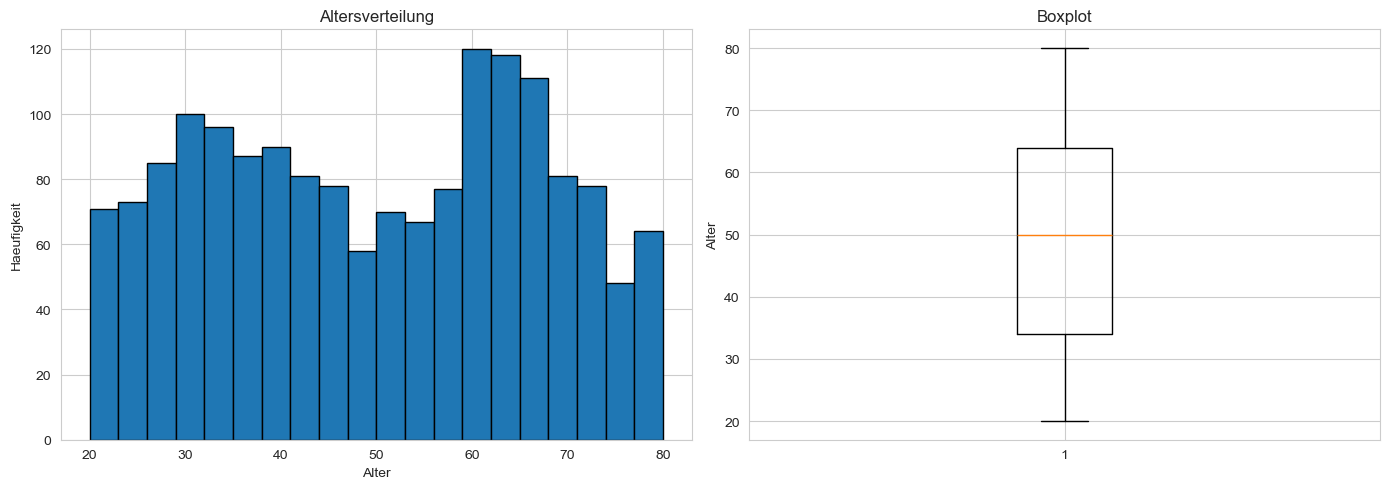

Median:  50.0
Mittelwert:  49.28


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(df['age'], bins=20, edgecolor='black')
ax[0].set_xlabel('Alter')
ax[0].set_ylabel('Haeufigkeit')
ax[0].set_title('Altersverteilung')

ax[1].boxplot(df['age'])
ax[1].set_ylabel('Alter')
ax[1].set_title('Boxplot')

plt.tight_layout()
plt.show()
print("Median: ", df['age'].median())
print("Mittelwert: ", round(df['age'].mean(), 2))

Die Altersverteilung ist relativ ausgeglichen, man sieht eine leichte Häufung zwischen 60 und 70. Der Median liegt bei 50 Jahren. Der Mittelwert bei 49,28. Ausreißer gibt es im Boxplot nicht, dies liegt daran, dass Probanden unter 20 rausgefiltert wurden und in dem Fragebogen bei 80 gecapt wurde, 80 steht für 80 und älter.

## Teil 2: BMI Verteilung

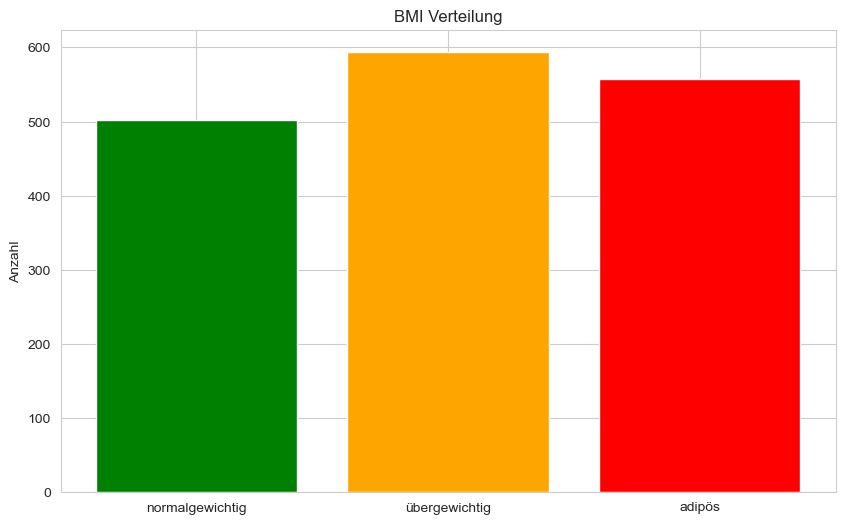

Normalgewichtig: 502 (30.4%)
Übergewichtig: 594 (35.9%)
Adipös: 557 (33.7%)


In [4]:
# Kategorien explizit in richtiger Reihenfolge definieren
reihenfolge = [0, 1, 2]
labels = ['normalgewichtig', 'übergewichtig', 'adipös']
farben = ['green', 'orange', 'red']

counts = df['bmi_cat'].value_counts().reindex(reihenfolge, fill_value=0)

plt.bar(labels, counts.values, color=farben)
plt.ylabel('Anzahl')
plt.title('BMI Verteilung')
plt.show()

print(f"Normalgewichtig: {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"Übergewichtig: {counts[1]} ({counts[1]/len(df)*100:.1f}%)")
print(f"Adipös: {counts[2]} ({counts[2]/len(df)*100:.1f}%)")

Die Verteilung der Gewichtsklassen ist relativ ausgeglichen. Die meisten sind übergewichtig (35,9%), adipös sind fast genau 1/3, normalgewichtig 30,4%.

## Teil 3: weitere demografische Angaben

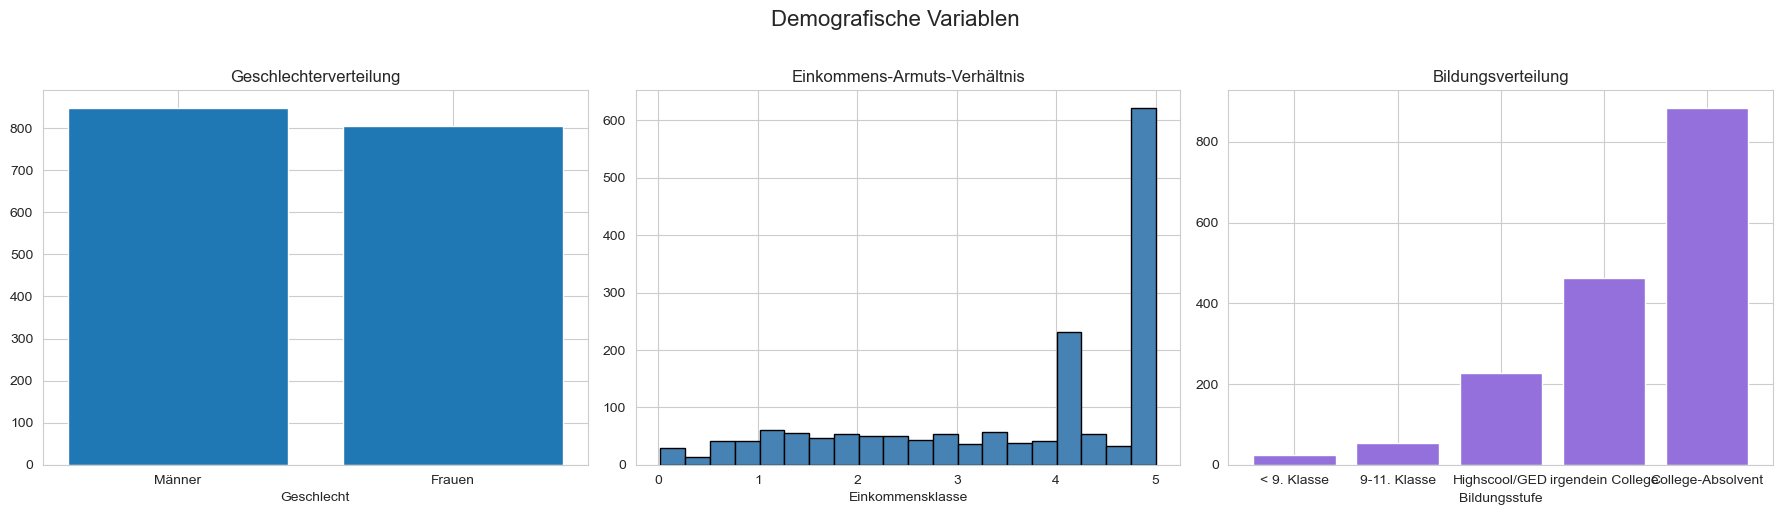

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

gender_counts = df['gender'].value_counts().reindex([1.0, 2.0], fill_value=0)
ax[0].bar(['Männer', 'Frauen'], gender_counts.values)
ax[0].set_xlabel('Geschlecht')
ax[0].set_title('Geschlechterverteilung')

ax[1].hist(df['income'], bins=20, color='steelblue', edgecolor='black')
ax[1].set_xlabel('Einkommensklasse')
ax[1].set_title('Einkommens-Armuts-Verhältnis')

ax[2].bar(
    ['< 9. Klasse', '9-11. Klasse', 'Highscool/GED', 'irgendein College', 'College-Absolvent'],
    df['education_lvl'].value_counts().reindex([1.0, 2.0, 3.0, 4.0, 5.0], fill_value=0).values,
    color='mediumpurple'
)
ax[2].set_xlabel('Bildungsstufe')
ax[2].set_title('Bildungsverteilung')

plt.suptitle('Demografische Variablen', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

- Wir sehen, dass der Datensetz recht balanciert zwischen Männern und Frauen ist.
- Über die Hälfte der Probanden hat ein Einkommen, das 5x und höher über der Armutsgrenze liegt. Dies kann darauf hindeuten, dass der Datensatz für den Einfluss von Einkommen auf Adipositas keine großen Aussagen zulassen wird, weil es diese Häufung gibt.
- Der Großteil der Probanden (>800) sind College-Absolventen, auch hier lässt sich eine Häufung erkennen. Dies kann ebenso die Aussagekraft einer möglichen Korrelation mindern.

## Teil 4: Lifestyle

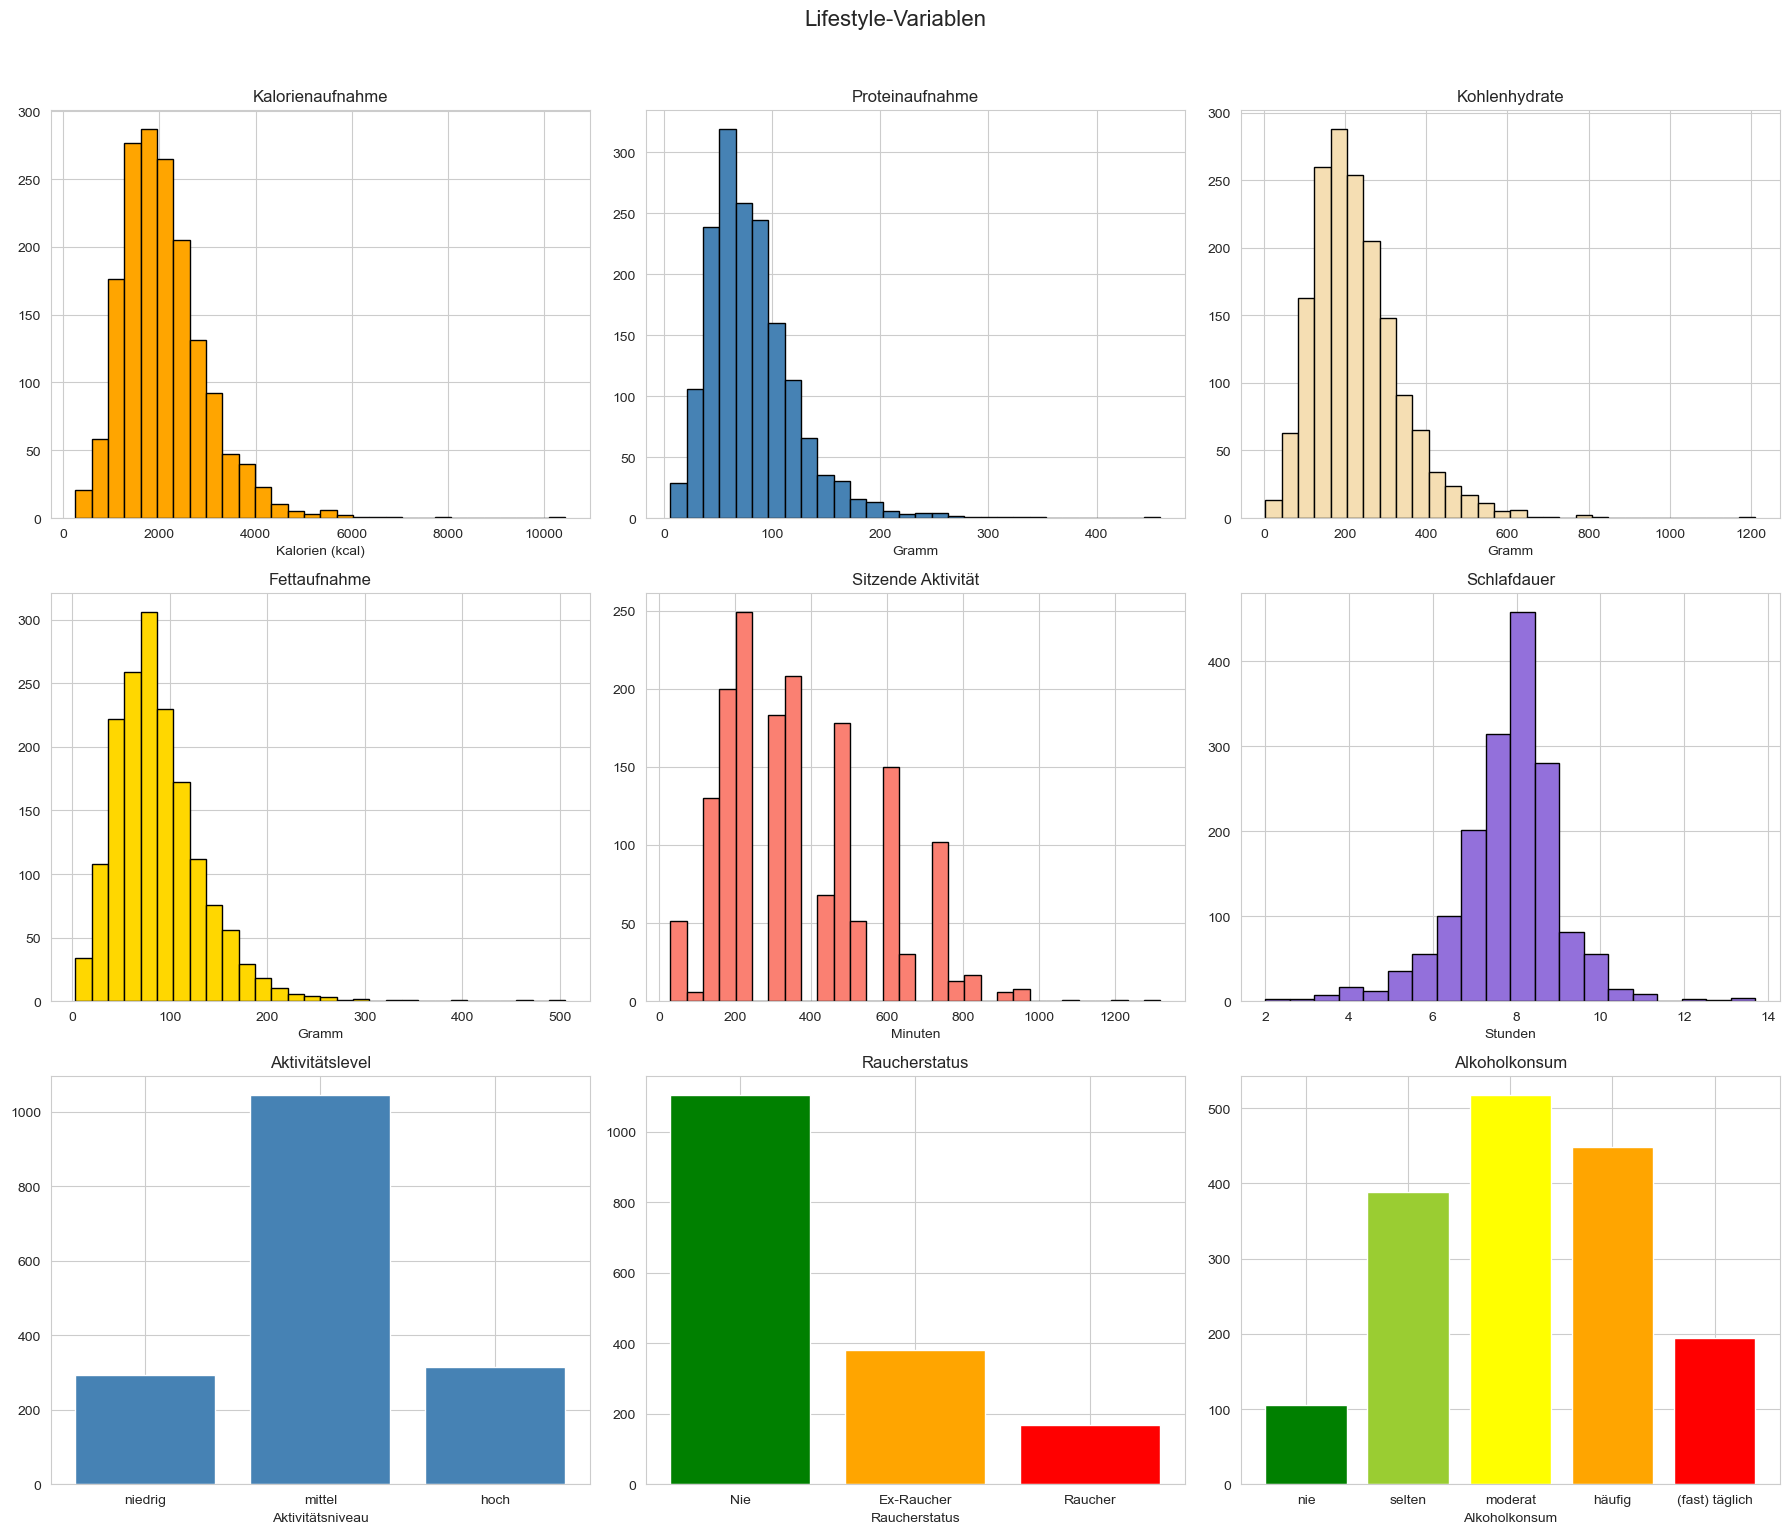

In [6]:
fig, ax = plt.subplots(3, 3, figsize=(18, 15))
ax = ax.flatten()

ax[0].hist(df['kcal'], bins=30, color='orange', edgecolor='black')
ax[0].set_xlabel('Kalorien (kcal)')
ax[0].set_title('Kalorienaufnahme')

ax[1].hist(df['protein'], bins=30, color='steelblue', edgecolor='black')
ax[1].set_xlabel('Gramm')
ax[1].set_title('Proteinaufnahme')

ax[2].hist(df['carbs'], bins=30, color='wheat', edgecolor='black')
ax[2].set_xlabel('Gramm')
ax[2].set_title('Kohlenhydrate')

ax[3].hist(df['fat'], bins=30, color='gold', edgecolor='black')
ax[3].set_xlabel('Gramm')
ax[3].set_title('Fettaufnahme')

ax[4].hist(df['sedentary_act_min'], bins=30, color='salmon', edgecolor='black')
ax[4].set_xlabel('Minuten')
ax[4].set_title('Sitzende Aktivität')

ax[5].hist(df['sleep_avg'], bins=20, color='mediumpurple', edgecolor='black')
ax[5].set_xlabel('Stunden')
ax[5].set_title('Schlafdauer')

activity_labels = {0: 'niedrig', 1: 'mittel', 2: 'hoch'}
activity_counts = df['activity_level'].value_counts().reindex([0, 1, 2], fill_value=0)
ax[6].bar(activity_labels.values(), activity_counts.values, color='steelblue')
ax[6].set_xlabel('Aktivitätsniveau')
ax[6].set_title('Aktivitätslevel')

smoke_labels = {0.0: 'Nie', 1.0: 'Ex-Raucher', 2.0: 'Raucher'}
smoke_counts = df['smoke_status'].value_counts().reindex([0.0, 1.0, 2.0], fill_value=0)
ax[7].bar(smoke_labels.values(), smoke_counts.values, color=['green', 'orange', 'red'])
ax[7].set_xlabel('Raucherstatus')
ax[7].set_title('Raucherstatus')

alcohol_labels = {1: 'kein', 2: 'gering', 3: 'moderat', 4: 'hoch'}
alcohol_counts = df['alcohol'].value_counts().reindex([1, 2, 3, 4], fill_value=0)
alcohol_labels = {0: 'nie', 1: 'selten', 2: 'moderat', 3: 'häufig', 4: '(fast) täglich'}
alcohol_counts = df['alcohol'].value_counts().reindex([0, 1, 2, 3, 4], fill_value=0)
ax[8].bar(alcohol_labels.values(), alcohol_counts.values, color=['green', 'yellowgreen', 'yellow', 'orange', 'red'])
ax[8].set_xlabel('Alkoholkonsum')
ax[8].set_title('Alkoholkonsum')

plt.suptitle('Lifestyle-Variablen', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

- Nährstoffe: annähernd normalverteilt mit Ausreißern nach rechts. Wir betrachen vor allem die Kalorien genauer: Wir sehen die größte Anzahl bei ca. 2000 kcal.
- sitzende Aktivität: es fällt auf, dass es Lücken in dem Histogramm gibt. Die meisten Werte treten bei knapp über 200min pro Tag auf.
- Schlaf: annähernd normalverteilt, Maximum bei ca. 8h Schlaf. Das passt zu der Schlafempfehlung der WHO von ca. 8h/Tag.
- Aktivität: Die meisten Probanden sind in der mittleren Kategorie (knapp > 1000), niedrig und hoch sind jeweils zwischen 200-400 Probanden.
- Rauchen: Die meisten Probanden (> 1000) rauchen nicht.
- Alkohol: ist in den mittleren Kategorien relativ gleichmäßig verteilt, die meisten sind in der Kategorie "moderat", die wenigsten bei "nie"



## Teil 5: Alter vs BMI

C:\Windows\Temp\ipykernel_43136\1727990411.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([normal, ueber, adi], labels=['normalgewichtig', 'übergewichtig', 'adipös'])


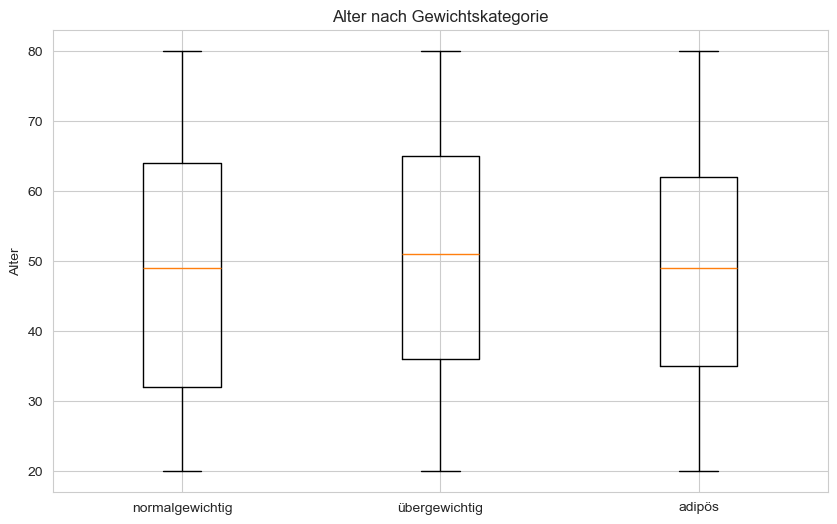

Durchschnitt normalgewichtig: 48.5
Durchschnitt übergewichtig: 50.4
Durchschnitt adipös: 48.7


In [7]:
normal = df[df['bmi_cat'] == 0]['age']
ueber = df[df['bmi_cat'] == 1]['age']
adi = df[df['bmi_cat'] == 2]['age']

plt.figure(figsize=(10, 6))
plt.boxplot([normal, ueber, adi], labels=['normalgewichtig', 'übergewichtig', 'adipös'])
plt.ylabel('Alter')
plt.title('Alter nach Gewichtskategorie')
plt.show()

print(f"Durchschnitt normalgewichtig: {normal.mean():.1f}")
print(f"Durchschnitt übergewichtig: {ueber.mean():.1f}")
print(f"Durchschnitt adipös: {adi.mean():.1f}")

Die Boxplots unterscheiden sich nicht stark. Übergewichtige Probanden sind tendentiell etwas älter als normalgewichtige und adipöse. Bei normalgewichtigen ist die Box länger, was eine durchschnittlich breitere Streuung des Alters in dieser Kategorie zeigt.

## Teil 6: kcal vs BMI

C:\Windows\Temp\ipykernel_43136\1703397807.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='bmi_cat_str', y='kcal',


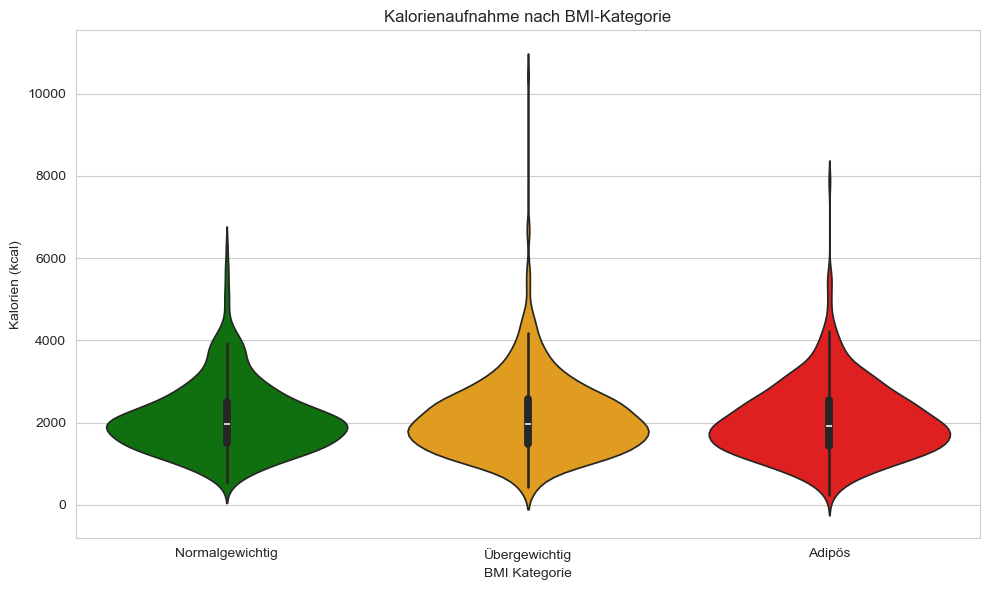

Normalgewichtig: Median 1970 kcal | Mittelwert 2108 kcal
Übergewichtig: Median 1970 kcal | Mittelwert 2126 kcal
Adipös: Median 1920 kcal | Mittelwert 2044 kcal


In [8]:
df['bmi_cat_str'] = df['bmi_cat'].map({0: 'Normalgewichtig', 1: 'Übergewichtig', 2: 'Adipös'})

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x='bmi_cat_str', y='kcal',
               order=['Normalgewichtig', 'Übergewichtig', 'Adipös'],
               palette={'Normalgewichtig': 'green', 'Übergewichtig': 'orange', 'Adipös': 'red'}, ax=ax)
ax.set_xlabel('BMI Kategorie')
ax.set_ylabel('Kalorien (kcal)')
ax.set_title('Kalorienaufnahme nach BMI-Kategorie')
plt.tight_layout()
plt.show()

# Mediane und Mittelwerte ausgeben
for kat, label in {0: 'Normalgewichtig', 1: 'Übergewichtig', 2: 'Adipös'}.items():
    median = df[df['bmi_cat'] == kat]['kcal'].median()
    mean = df[df['bmi_cat'] == kat]['kcal'].mean()
    print(f"{label}: Median {median:.0f} kcal | Mittelwert {mean:.0f} kcal")

Überraschenderweise unterscheiden sich die Mediane der Gruppen kaum, normal und übergewichtig liegen bei 1970 kcal, adipös sogar darunter mit 1920 kcal. Der Mittelwert der Übergewichtigen liegt mit 2126 kcal leicht über dem der normalgewichtigen, der Mittelwert der adipösen ist mit 2044 kcal am niedrigsten. <br>
Bei der Form der Violin-Plots fällt auf, dass bei den Normalgewichtigen der Bauch etwas spitzer ist, es scheint also mehr Werte um den Median zu geben. Bei den anderen beiden Kategorien sind die Bäuche etwas runder, was für eine breitere Streuung spricht.

## Teil 7: Geschlecht vs BMI

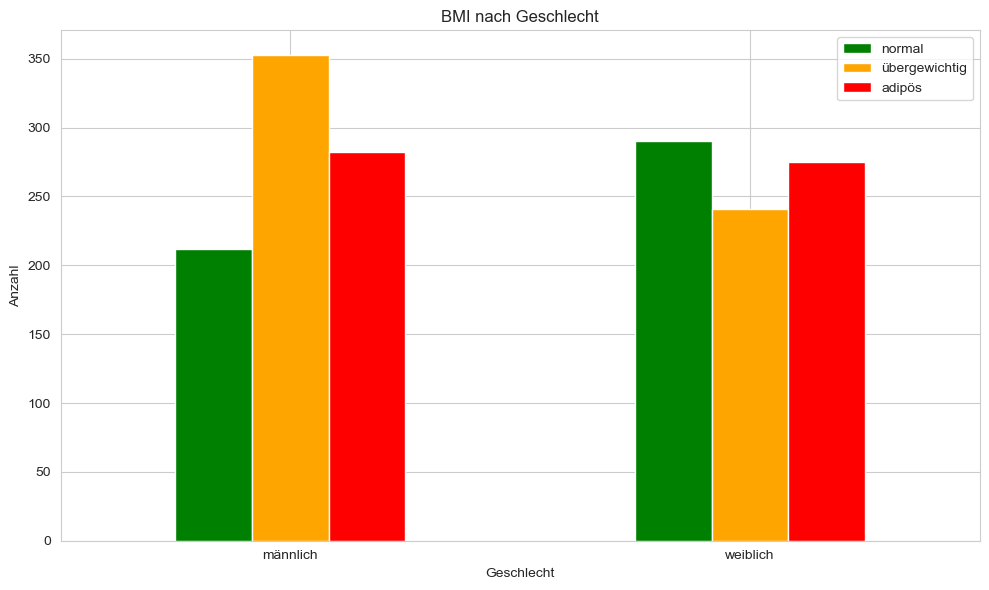

          normal  übergewichtig  adipös
männlich     212            353     282
weiblich     290            241     275
Adipöse Männer: 282 (17.1%)
Adipöse Frauen: 275 (16.6%)


In [9]:
cross = pd.crosstab(df['gender'], df['bmi_cat'])
cross.columns = ['normal', 'übergewichtig', 'adipös']
cross.index = ['männlich', 'weiblich']

cross.plot(kind='bar', figsize=(10, 6), color=['green', 'orange', 'red'])
plt.xlabel('Geschlecht')
plt.ylabel('Anzahl')
plt.title('BMI nach Geschlecht')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

print(cross)

# Adipöse nach Geschlecht Statistik
adipoes_maenner = df[(df['bmi_cat'] == 2) & (df['gender'] == 1.0)]
adipoes_frauen = df[(df['bmi_cat'] == 2) & (df['gender'] == 2.0)]
print(f"Adipöse Männer: {len(adipoes_maenner)} ({len(adipoes_maenner)/len(df)*100:.1f}%)")
print(f"Adipöse Frauen: {len(adipoes_frauen)} ({len(adipoes_frauen)/len(df)*100:.1f}%)")

Wir sehen, dass Männer absolut häufiger übergewichtig sind als Frauen (353 vs. 241), 
während Frauen häufiger normalgewichtig sind (290 vs. 212). Bei Adipositas ist 
der Unterschied gering: 17,1% der Probanden sind adipöse Männer, 16,6% adipöse 
Frauen. Insgesamt scheinen Männer in diesem Datensatz also tendenziell eher zu 
Übergewicht zu neigen, während Frauen häufiger normalgewichtig sind. Der 
Unterschied bei Adipositas ist jedoch kaum aussagekräftig.

## Teil 8: Korrelationen

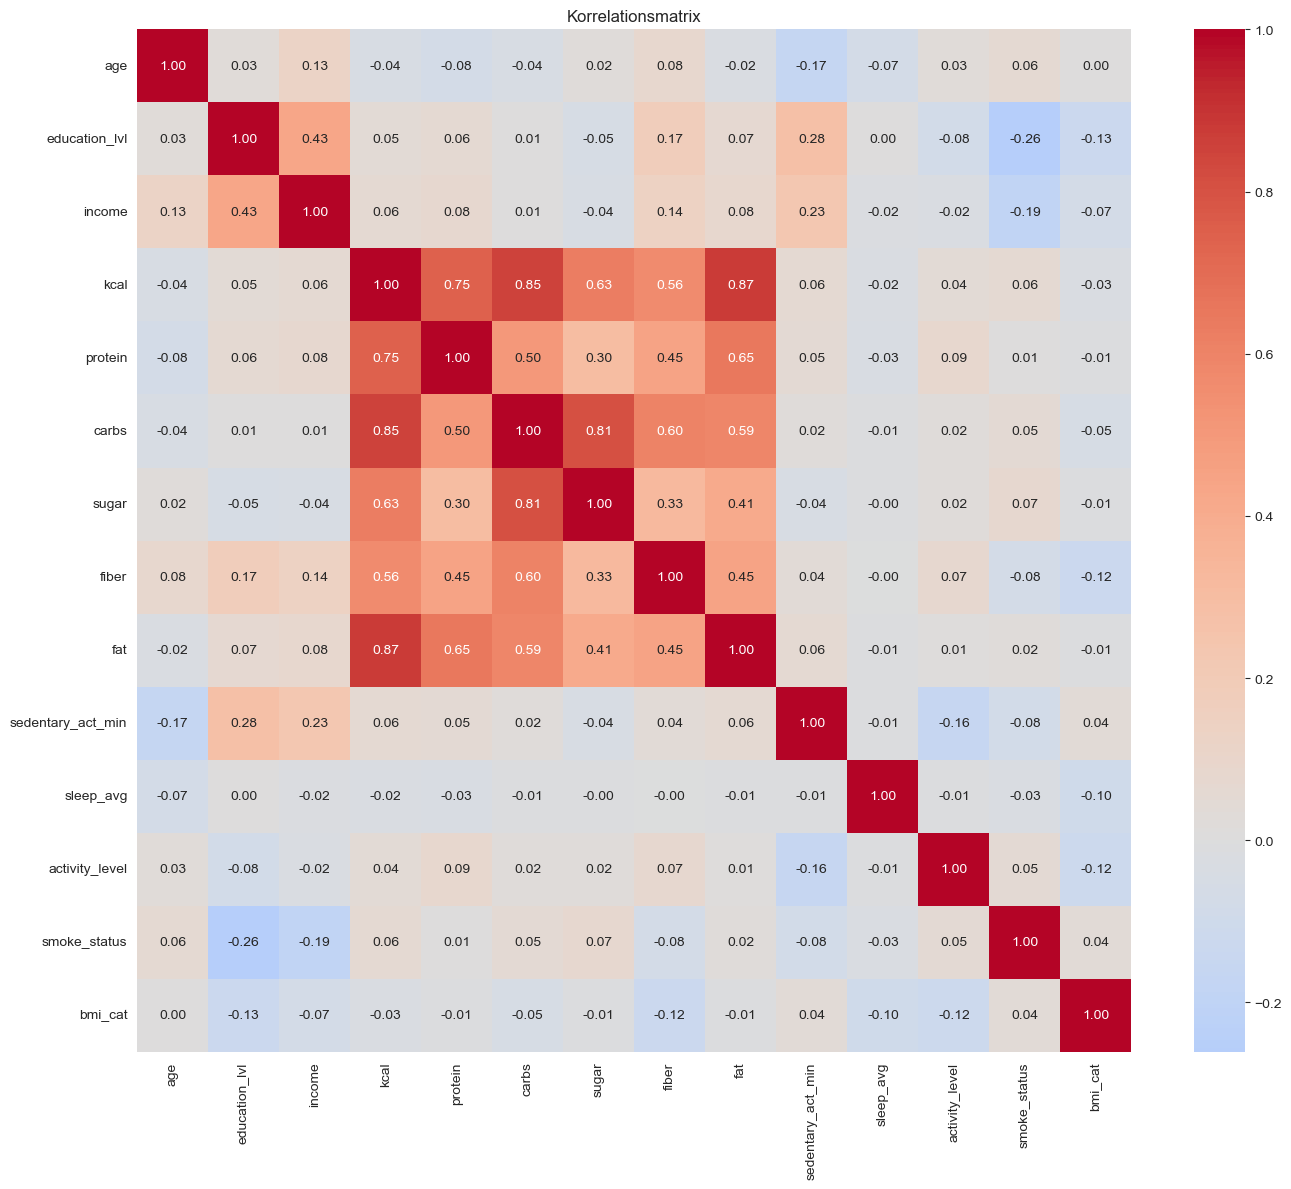

Korrelation mit BMI:
bmi_cat              1.000000
sedentary_act_min    0.038193
smoke_status         0.037331
age                  0.002316
protein             -0.007038
fat                 -0.011160
sugar               -0.012765
kcal                -0.028891
carbs               -0.046374
income              -0.070107
sleep_avg           -0.097777
activity_level      -0.118189
fiber               -0.123274
education_lvl       -0.132396
Name: bmi_cat, dtype: float64


In [10]:
cols = ['age', 'education_lvl', 'income', 'kcal', 'protein', 'carbs', 'sugar', 
        'fiber', 'fat', 'sedentary_act_min', 'sleep_avg', 'activity_level', 
        'smoke_status', 'bmi_cat']
corr = df[cols].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Korrelationsmatrix')
plt.tight_layout()
plt.show()
print("Korrelation mit BMI:")
print(corr['bmi_cat'].sort_values(ascending=False))

Die Korrelations-Heatmap zeigt keine starke positive Korrelation der BMI-Kategorie mit einer der Variablen. Die stärkste negative Korrelation haben Bildungslevel, Ballaststoffaufnahme und sportliche Aktivität. Dabei muss beim Bildungslevel aber beachtet werden, dass keine Gleichverteilung der Werte vorliegt (vgl. Teil 3), sondern deutlich mehr Probanden mit höheren Bildungsstufen als niedrigeren. Dies kann die Korrelation verzerren.

## Teil 9: Interaktive Plots

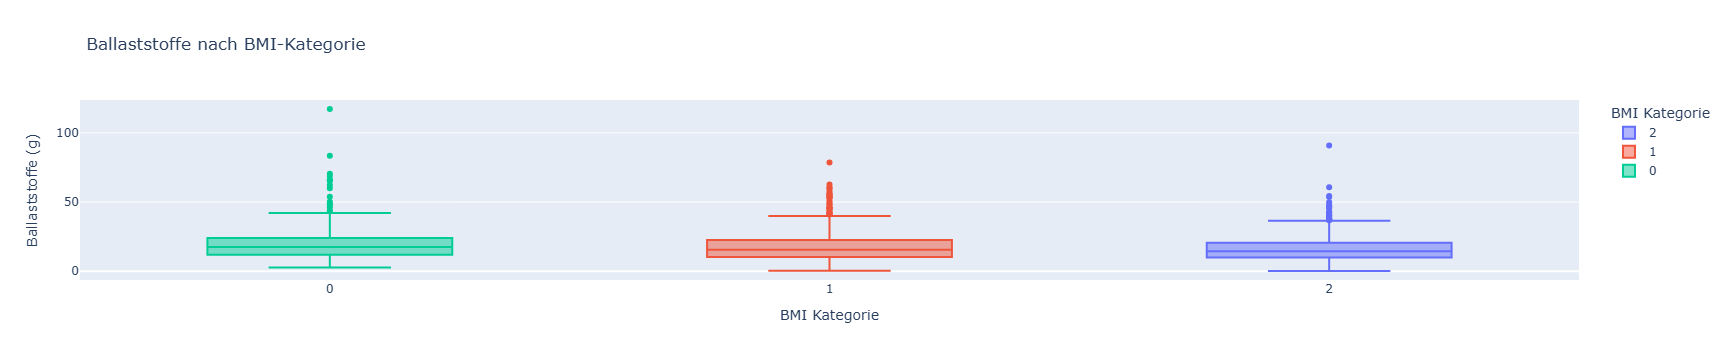

In [11]:
# fiber vs. bmi_cat
fig = px.box(df, x='bmi_cat', y='fiber',
              color='bmi_cat',
              labels={'bmi_cat': 'BMI Kategorie',
                      'fiber': 'Ballaststoffe (g)'},
              title='Ballaststoffe nach BMI-Kategorie')
fig.show()

Man sieht, dass die Ballaststoffaufnahme bei den Adipöse niedriger ist. Die Mediane liegen bei 17,6 für Normalgewichtige, 15,5 für Übergewichtige und 14,5 für Adipöse.

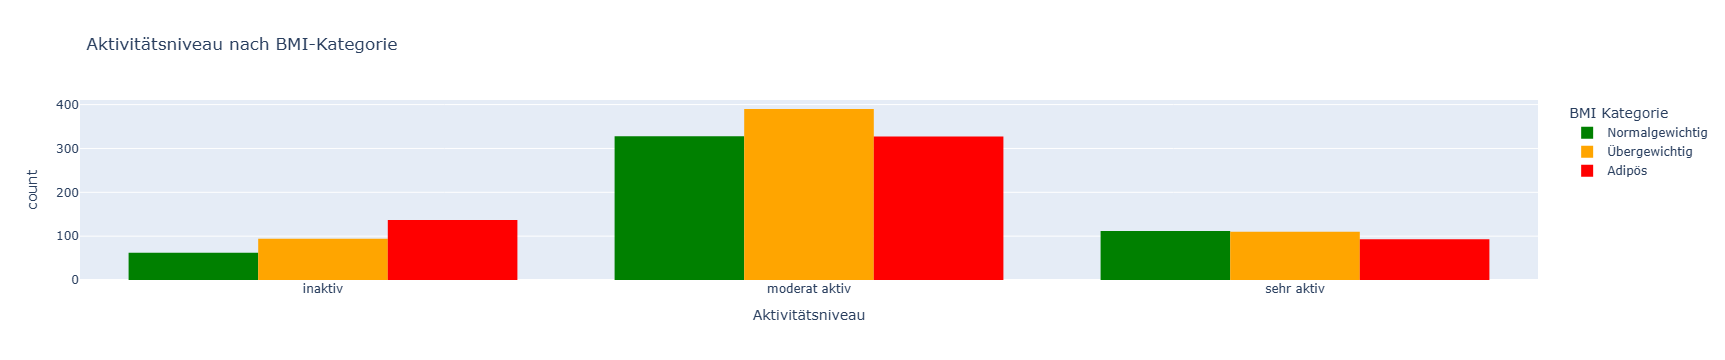

In [12]:
df['activity_str'] = df['activity_level'].map({0: 'inaktiv', 1: 'moderat aktiv', 2: 'sehr aktiv'})

fig = px.histogram(df, x='activity_str', color='bmi_cat',
                   barmode='group',
                   category_orders={'activity_str': ['inaktiv', 'moderat aktiv', 'sehr aktiv'],
                                    'bmi_cat': [0, 1, 2]},
                   color_discrete_map={0: 'green', 1: 'orange', 2: 'red'},
                   labels={'activity_str': 'Aktivitätsniveau',
                           'bmi_cat': 'BMI Kategorie',
                           'count': 'Anzahl'},
                   title='Aktivitätsniveau nach BMI-Kategorie')

fig.for_each_trace(lambda t: t.update(name={'0': 'Normalgewichtig',
                                             '1': 'Übergewichtig',
                                             '2': 'Adipös'}[t.name]))
fig.show()

Man sieht, dass in der inaktiven Kategorie anteilig am meisten Adipöse sind, in der moderat aktiven anteilig am meisten Übergewichtige und in der sehr aktiven anteilig knapp am meisten Normalgewichtige, hierbei ist der Unterschied aber nicht ganz so klar. Es fällt auch noch auf, dass in der moderat aktiven Kategorie insgesamt am meisten Probanden sind.

## Teil 10: Scatter Plots

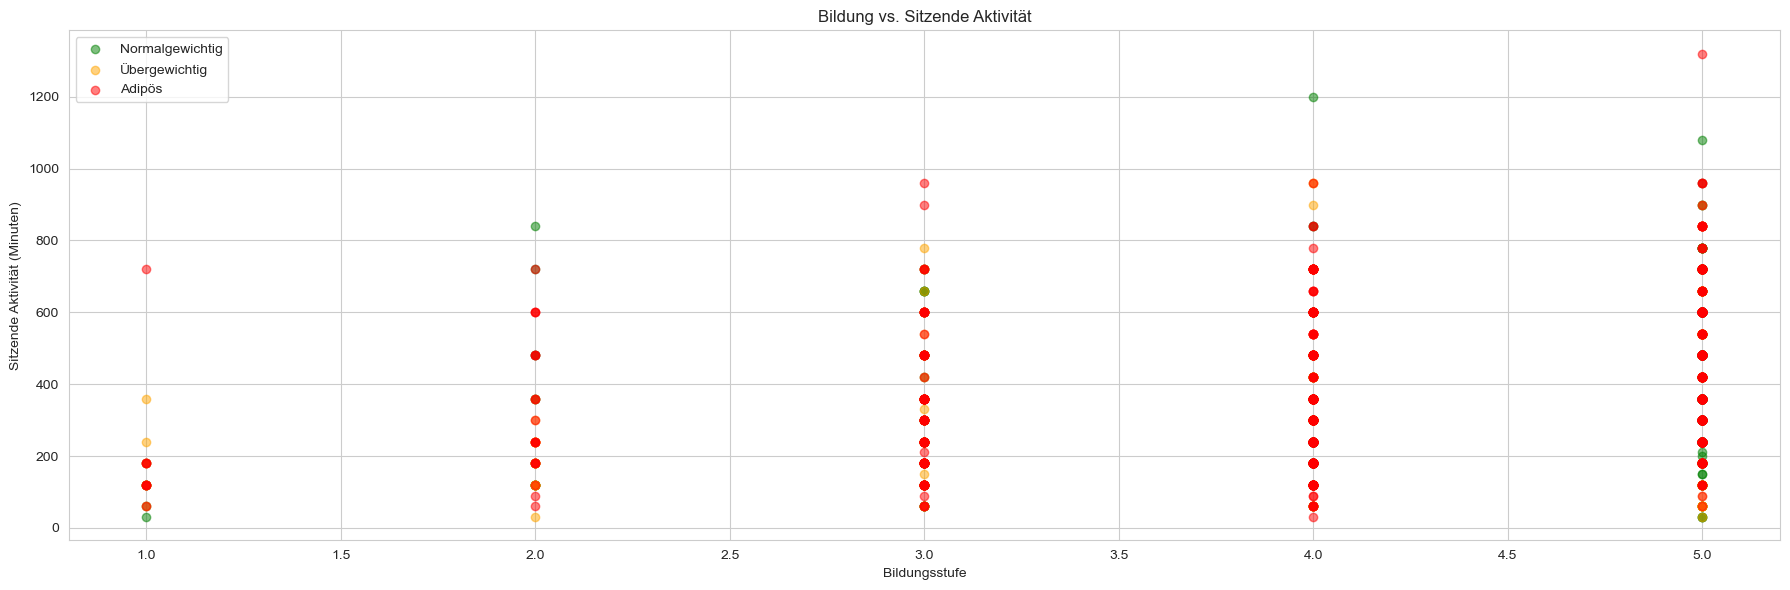

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(18, 6))
farben = {0: 'green', 1: 'orange', 2: 'red'}
labels = {0: 'Normalgewichtig', 1: 'Übergewichtig', 2: 'Adipös'}

for kat in [0, 1, 2]:
    subset = df[df['bmi_cat'] == kat]
    ax.scatter(subset['education_lvl'], subset['sedentary_act_min'],
               c=farben[kat], label=labels[kat], alpha=0.5)
ax.set_xlabel('Bildungsstufe')
ax.set_ylabel('Sitzende Aktivität (Minuten)')
ax.set_title('Bildung vs. Sitzende Aktivität')
ax.legend()
plt.tight_layout()
plt.show()

In diesem Scatterplot ist auffällig, dass mit steigendem Bildungslevel auch die Dauer an sitzender Aktivität steigt. Dies könnte daran liegen, dass Akademiker tendentiell eher Schreibtischjobs haben. Menschen ohne Schulabschluss hingegen könnten vermutlich eher körperliche Jobs ausüben.
Eine Aussage über den Zusammenhang zum BMI ist kaum zu treffen, da die Punkte sich sehr überlagern. Da ich den Zusammenhang zwischen Bildungslevel und sitzender Aktivität aber interessant fand, habe ich den Plot trotzdem stehen lassen.

## Zusammenfassung

In [14]:
print("ERKENNTNISSE")
print("=" * 50)

# Adipöse nach Geschlecht
print(f"Adipöse Männer: {len(adipoes_maenner)} ({len(adipoes_maenner)/len(df)*100:.1f}%)")
print(f"Adipöse Frauen: {len(adipoes_frauen)} ({len(adipoes_frauen)/len(df)*100:.1f}%)")
print()

# Kennzahlen pro BMI-Gruppe
for kat, label in {0: 'Normalgewichtig', 1: 'Übergewichtig', 2: 'Adipös'}.items():
    subset = df[df['bmi_cat'] == kat]
    print(f"--- {label} ---")
    print(f"  Durchschnittsalter:        {subset['age'].mean():.1f} Jahre")
    print(f"  Durchschnittliche kcal:    {subset['kcal'].mean():.0f} kcal")
    print(f"  Durchschnittlicher Schlaf: {subset['sleep_avg'].mean():.1f} Stunden")
    print(f"  Körperliche Inaktivität:   {subset['sedentary_act_min'].mean():.0f} Minuten")
    print(f"  Aktivitätsniveau:          {subset['activity_level'].mean():.2f}")
    print()

# Korrelation
print("Stärkste Korrelationen mit BMI-Kategorie:")
print("-" * 40)
korr = corr['bmi_cat'].drop('bmi_cat').sort_values(key=abs, ascending=False)
for var, wert in korr.items():
    richtung = "positiv" if wert > 0 else "negativ"
    print(f"  {var:<20} {wert:+.3f} ({richtung})")

ERKENNTNISSE
Adipöse Männer: 282 (17.1%)
Adipöse Frauen: 275 (16.6%)

--- Normalgewichtig ---
  Durchschnittsalter:        48.5 Jahre
  Durchschnittliche kcal:    2108 kcal
  Durchschnittlicher Schlaf: 8.0 Stunden
  Körperliche Inaktivität:   369 Minuten
  Aktivitätsniveau:          1.10

--- Übergewichtig ---
  Durchschnittsalter:        50.4 Jahre
  Durchschnittliche kcal:    2126 kcal
  Durchschnittlicher Schlaf: 7.8 Stunden
  Körperliche Inaktivität:   353 Minuten
  Aktivitätsniveau:          1.03

--- Adipös ---
  Durchschnittsalter:        48.7 Jahre
  Durchschnittliche kcal:    2044 kcal
  Durchschnittlicher Schlaf: 7.7 Stunden
  Körperliche Inaktivität:   387 Minuten
  Aktivitätsniveau:          0.92

Stärkste Korrelationen mit BMI-Kategorie:
----------------------------------------
  education_lvl        -0.132 (negativ)
  fiber                -0.123 (negativ)
  activity_level       -0.118 (negativ)
  sleep_avg            -0.098 (negativ)
  income               -0.070 (negativ